# 07. Data Structures_Tree

앞서 선형 자료 구조 (Linear data structure)인 Array, Stack, Queue, Linked list에 대해 배웠습니다. 이제 남은 영역은 다음과 같고, 이번에는 Tree에 대해서 한 번 배워봅시다.

- Binary Tree: 각 Node가 두 개의 자식 Node를 가지는 트리 구조
- Red Black Tree: 색깔을 활용해 자체적으로 양 쪽 밸런스를 잡아주는 트리 구조
- Hashmaps: 키와 값을 가지는 자료 구조
- Tries: 단어의 저장과 검색을 빠르게 해주는 트리 구조
- Graphs: Edge로 이어진 Node의 모음

## 트리 (Tree)란?
- 트리 (Tree)는 이름에서 보다시피 나무와 같은 계층을 가지는 자료 구조입니다. 다만, `뿌리 노드 (root node)`가 최상단에 위치하고, `잎 노드 (leaf node)`가 최하단에 위치하는 형태로 구성됩니다.

<img src="imgsrc/BST_Example.png" alt="Binary Tree">

트리는 연결 리스트의 일종으로 각 노드가 `자식 노드 (child node)`에 대한 정보를 가지고 있습니다. 다만, 연결 리스트와는 다르게 하나의 노드가 여러개의 자식 노드를 가질 수 있습니다. 트리는 일반적으로 다음과 같은 규칙을 따르는 구조로 되어 있습니다.
- 각 노드는 자신의 값을 가집니다.
- 각 노드는 자식 노드를 가질 수 있습니다 (그렇지 않을 수도 있습니다).
- 각 노드는 하나의 부모 노드를 가질 수 있습니다 (뿌리 노드는 예외로 부모 노드가 없습니다).

$ 연결 리스트 (Linked List) $

``` python
node -> node -> node
```


$ 트리 (Tree) $

``` python
         > node
      > node
   > node
> node
         > node
      > node
         > node
      > node
   > node
      > node
```



## 이진 트리 (Binary Tree)란?
- 트리는 일반적으로 어떤 방법이든 정렬된 상태가 아니라면 유용하지 않습니다. 그리고 정렬된 트리 중 가장 유명한 것이 바로 이진 트리 (Binary Tree)입니다. 종종 자료 검색의 특성을 반영해, 이진 탐색 트리 (Binary Search Tree, BST)라고도 불립니다. BST는 다음과 같은 추가적인 규칙을 따르는 트리입니다.
    - 각 노드는 최대 두 개의 자식 노드를 가질 수 있습니다 (왼쪽 자식과 오른쪽 자식)
    - 왼쪽 자식 노등의 값은 항상 부모 노드의 값보다 작아야 합니다.
    - 오른쪽 자식 노드의 값은 항상 부모 노드의 값보다 커야 합니다.
    - 모든 노드는 고유한 값을 가져야 합니다 (중복된 값은 허용되지 않습니다).
- 챕터 03. Time_complexity의 예제 13에서 다뤘던 `병뚜껑에 적힌 숫자 맞추기`랑 비슷합니다.

## 예제37. 이진 트리 구현하기
- 이진 트리를 한 번 구현해봅시다. 위에 적힌 특성을 바탕으로 `BSTNode` 클래스의 `__init__` 메서드와 `insert` 메서드를 작성해보죠.
- `BSTNode` 클래스는 다음과 같은 속성을 가집니다.
    - `value`: 노드가 저장하는 값입니다. 이 예제에서는 `User` 객체가 될 것입니다. 또한 `User` 클래스에는 이미 구현된 연산자 메서드가 있어 `<`, `>`, `==` 연산을 사용할 수 있습니다.
    - `left`: 왼쪽 자식 노드를 가리키는 포인터입니다. 초기값은 `None`입니다. 입력에 따라 다른 BSTNode를 가리키게 됩니다.
    - `right`: 오른쪽 자식 노드를 가리키는 포인터입니다. 초기값은 `None`입니다. 입력에 따라 다른 BSTNode를 가리키게 됩니다.
- `insert` 메서드는 다음과 같은 로직으로 작동합니다.
    1. 만약 현재 노드에 값이 없다면, 입력된 값을 사용하고 끝냅니다.
    2. 만약 현재 노드의 값과 동일한 값이 입력되었다면, 중복은 허용하지 않기 때문에 아무 작업도 하지 않고 끝냅니다.
    3. 만약 현재 노드의 값보다 작은 값이 입력되었고, 현재 노드에 `left`가 없다면, 새로운 `left`를 생성하고 값을 할당한 후 끝냅니다.
    4. 만약 현재 노드의 값보다 작은 값이 입력되었고, 현재 노드에 `left`가 있다면, `left` 노드의 `insert` 메서드를 재귀적으로 호출하여 값을 삽입합니다.
    5. 현재 노드의 큰 값에 대해서는 `right` 노드에 대해서 동일하게 처리합니다.

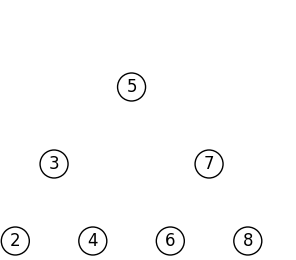

In [17]:
class BSTNode:
    def __init__(self, val=None):
        self.left = None
        self.right = None
        self.val = val

    def insert(self, val):
        if self.val is None:
            self.val = val
            return None
        if val == self.val:
            return None
        if val < self.val:
            if self.left is None:
                self.left = BSTNode(val)
            else:
                self.left.insert(val)
        else:
            if self.right is None:
                self.right = BSTNode(val)
            else:
                self.right.insert(val)

# 테스트 코드
root = BSTNode()
root.insert(5)
root.insert(3)
root.insert(7)
root.insert(2)
root.insert(4)
root.insert(6)
root.insert(8)

# 트리 시각화
import matplotlib.pyplot as plt

def draw_tree(node, x=0, y=0, level=1):
    if node is not None:
        plt.text(x, y, str(node.val), fontsize=12, ha='center', va='center',
                 bbox=dict(facecolor='white', edgecolor='black', boxstyle='circle'))
        draw_tree(node.left, x - 1 / (2 ** level), y - 1, level + 1)
        draw_tree(node.right, x + 1 / (2 ** level), y - 1, level + 1)

plt.figure(figsize=(2, 1))
draw_tree(root)
plt.axis('off')
plt.show()

이진 트리에서의 `삽입 (insertion)`은 매우 빠릅니다. 이미 존재하는 트리에 새로운 숫자를 배치할 때, 몇 번의 비교를 해야하는지를 생각해보면 좀 더 확실합니다. 1~100까지의 숫자 중 1을 root로 잡고, 순차적으로 삽입하는 극단적인 불균형 상태의 트리가 아니라 양 쪽의 균형이 잘 맞는 경우에, 최대 7번의 비교로 100을 삽입할 수 있습니다. 즉, `삽입 (insertion)`의 시간 복잡도는 $O(log n)$입니다.

예제 38. 최대값, 최소값 찾기
- BST 알고리즘의 장점 중 하나는 최대값과 최소값을 빠르게 찾을 수 있다는 것입니다. 최대값은 오른쪽 자식 노드를 따라가면 되고, 최소값은 왼쪽 자식 노드를 따라가면 됩니다. 따라서 최대값과 최소값을 찾는 시간 복잡도는 $O(log n)$입니다.

In [1]:
class BSTNode:
    def get_min(self):
        if self.val is None:
            return None
        node = self
        while node.left is not None:
            node = node.left
        return node.val

    def get_max(self):
        if self.val is None:
            return None
        node = self
        while node.right is not None:
            node = node.right
        return node.val

    # don't touch below this line

    def __init__(self, val=None):
        self.left = None
        self.right = None
        self.val = val

    def insert(self, val):
        if self.val is None:
            self.val = val
            return

        if self.val == val:
            return

        if val < self.val:
            if self.left:
                self.left.insert(val)
                return
            self.left = BSTNode(val)
            return

        if self.right:
            self.right.insert(val)
            return
        self.right = BSTNode(val)

# 테스트 코드
root = BSTNode()
root.insert(5)
root.insert(3)
root.insert(7)
root.insert(2)
root.insert(4)
root.insert(6)
root.insert(8)
print("최소값:", root.get_min())  # 출력: 최소값: 2
print("최대값:", root.get_max())  # 출력: 최대값: 8

최소값: 2
최대값: 8


## 예제38. 이진 트리의 삭제 (Delete) 구현
- 재귀적 `삭제 (Delete)` 메서드를 구현해봅시다. 값이 있는지를 찾고, 존재하면 삭제합니다. 각각의 호출은 새로운 해당 노드가 삭제된 새로운 트리를 반환합니다. `삭제 (Delete)` 메서드는 다음과 같이 호출하므로 이 점을 기억하세요.

``` python
bst = bst.delete(value)
```

- `삭제 (Delete)`는 다음과 같이 구현합니다.
    1. 현재 노드가 `None`이면, 삭제할 값이 트리에 존재하지 않는 것이므로 `None`을 반환합니다. 이 경우는 트리 자체가 비어있거나, 트리의 잎에 도달했을 때 발생합니다.
    2. 만약 삭제할 값이 현재 노드의 값보다 작다면
        1. `left` 자식 노드에서 삭제를 시도합니다. 그 후 결과를 `left`에 할당합니다. 이렇게 하면 트리의 구조가 유지됩니다.
        2. 현재 노드를 반환합니다.
    3. 만약 삭제할 값이 현재 노드의 값보다 크다면
        1. `right` 자식 노드에서 삭제를 시도합니다. 그 후 결과를 `right`에 할당합니다. 이렇게 하면 트리의 구조가 유지됩니다.
        2. 현재 노드를 반환합니다.
    4. 만약 삭제할 값이 현재 노드의 값과 같다면, 이 노드를 삭제해야 합니다. 이 경우는 세 가지 하위 케이스로 나뉩니다.
        1. 만약 `right` 자식 노드가 없다면, 왼쪽 자식 노드를 반환합니다. 이렇게 하면 현재 노드가 삭제되고, 왼쪽 자식이 그 자리를 차지하게 됩니다.
        2. 만약 `left` 자식 노드가 없다면, 오른쪽 자식 노드를 반환합니다. 이렇게 하면 현재 노드가 삭제되고, 오른쪽 자식이 그 자리를 차지하게 됩니다.
        3. 만약 `left`와 `right` 자식 노드가 모두 존재한다면, `successor` 노드를 찾아야 합니다. `successor`는 오른쪽 자식 노드에서 가장 작은 값을 가진 노드입니다. 이 노드는 현재 노드 바로 다음으로 큰 값을 가지고 있습니다.
            1. 현재 노드의 `right`를 기준으로 `left` 자식 노드를 따라가면서 가장 작은 값을 가진 노드를 찾습니다. `left`가 `None`인 노드가 `successor`입니다.
            2. 현재 노드의 값을 `successor`의 값으로 대체합니다. 
            3. `delete` 메서드를 재귀적으로 호출하여 `successor` 노드를 삭제합니다. 이 때, `successor` 노드는 오른쪽 자식 노드에서 가장 작은 값을 가진 노드이므로, `right` 자식 노드에서 삭제를 시도합니다.
            4. 현재 노드를 반환합니다.

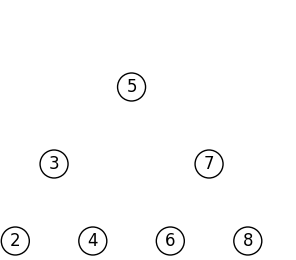

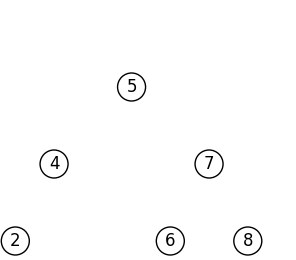

In [1]:
class BSTNode:
    def delete(self, val):
        if self.val is None:
            return None
        if val < self.val:
            if self.left is not None:
                self.left = self.left.delete(val)
        elif val > self.val:
            if self.right is not None:
                self.right = self.right.delete(val)
        else:
            if self.right is None:
                return self.left
            if self.left is None:
                return self.right
            successor_val = self.right.get_min()
            self.val = successor_val
            self.right = self.right.delete(successor_val)
        return self

    # don't touch below this line

    def __init__(self, val=None):
        self.left = None
        self.right = None
        self.val = val

    def insert(self, val):
        if self.val is None:
            self.val = val
            return

        if self.val == val:
            return

        if val < self.val:
            if self.left:
                self.left.insert(val)
                return
            self.left = BSTNode(val)
            return

        if self.right:
            self.right.insert(val)
            return
        self.right = BSTNode(val)

    def get_min(self):
        current = self
        while current.left is not None:
            current = current.left
        return current.val

    def get_max(self):
        current = self
        while current.right is not None:
            current = current.right
        return current.val

# 테스트 코드
root = BSTNode()
root.insert(5)
root.insert(3)
root.insert(7)
root.insert(2)
root.insert(4)
root.insert(6)
root.insert(8)

# 트리 시각화
import matplotlib.pyplot as plt

def draw_tree(node, x=0, y=0, level=1):
    if node is not None:
        plt.text(x, y, str(node.val), fontsize=12, ha='center', va='center',
                 bbox=dict(facecolor='white', edgecolor='black', boxstyle='circle'))
        draw_tree(node.left, x - 1 / (2 ** level), y - 1, level + 1)
        draw_tree(node.right, x + 1 / (2 ** level), y - 1, level + 1)
plt.figure(figsize=(2, 1))
draw_tree(root)
plt.axis('off')
plt.show()

root.delete(3)

# 트리 시각화
plt.figure(figsize=(2, 1))
draw_tree(root)
plt.axis('off')
plt.show()

`삭제 (delete)` 연산의 시간 복잡도는 $O(log n)$입니다. 왜냐하면 삭제할 노드를 찾는 과정이 트리의 높이에 비례하기 때문입니다. 트리가 균형 잡혀 있다면, 트리의 높이는 $log n$이므로 삭제 연산도 $O(log n)$이 됩니다. 하지만 트리가 극단적으로 불균형한 경우에는 최악의 경우 시간 복잡도가 $O(n)$이 될 수 있습니다.

## 예제39. 전위 순회 (Pre-order Traversal) 구현
- 트리의 모든 노드를 방문하는 방법 중 하나인 전위 순회 (Pre-order Traversal)를 구현해봅시다. 예를 들어 다음과 같은 트리가 있다고 가정할 때 전위 순회는 다음과 같은 순서로 노드를 방문합니다. [5, 3, 2, 7, 6, 8]
```
     5    
    / \   
  3    7  
 /    / \ 
2    6   8
```

- `전위 순회 (preorder)` 메서드도 재귀적으로 구현할 수 있습니다. 결과값으로 방문 순서에 따라 정렬된 리스트를 반환합니다.
- 다음과 같은 알고리즘으로 구현합니다.
  1. 현재 노드가 값을 가지고 있다면, `visited array`에 값을 할당하는 방법으로 방문합니다.
  2. `left` 자식 노드가 존재한다면, `preorder` 메서드를 재귀적으로 호출하여 방문합니다.
  3. `right` 자식 노드가 존재한다면, `preorder` 메서드를 재귀적으로 호출하여 방문합니다.
  4. 방문한 순서의 리스트를 반환합니다.


In [1]:
class BSTNode:
    def preorder(self, visited):
        if self.val is None:
            return visited

        visited.append(self.val)

        if self.left is not None:
            self.left.preorder(visited)
        if self.right is not None:
            self.right.preorder(visited)

        return visited

    # don't touch below this line

    def __init__(self, val=None):
        self.left = None
        self.right = None
        self.val = val

    def insert(self, val):
        if self.val is None:
            self.val = val
            return

        if self.val == val:
            return

        if val < self.val:
            if self.left:
                self.left.insert(val)
                return
            self.left = BSTNode(val)
            return

        if self.right:
            self.right.insert(val)
            return
        self.right = BSTNode(val)

# 테스트 코드
root = BSTNode()
root.insert(5)
root.insert(3)
root.insert(7)
root.insert(2)
root.insert(4)
root.insert(6)
root.insert(8)
print("전위 순회:", root.preorder([]))  # 출력: 전위 순회: [5, 3, 2, 4, 7, 6, 8]

전위 순회: [5, 3, 2, 4, 7, 6, 8]


## 예제40. 후위 순회 (Post-order Traversal) 구현
- 트리의 모든 노드를 방문하는 방법 중 하나인 후위 순회 (Post-order Traversal)를 구현해봅시다. 예를 들어 다음과 같은 트리가 있다고 가정할 때 후위 순회는 다음과 같은 순서로 노드를 방문합니다. [2, 3, 6, 8, 7, 5]
```
     5    
    / \   
  3    7  
 /    / \ 
2    6   8
```
- `후위 순회 (postorder)` 메서드도 재귀적으로 구현할 수 있습니다. 결과값으로 방문 순서에 따라 정렬된 리스트를 반환합니다.
- 다음과 같은 알고리즘으로 구현합니다.
  1. `left` 자식 노드가 존재한다면, `postorder` 메서드를 재귀적으로 호출하여 방문합니다.
  2. `right` 자식 노드가 존재한다면, `postorder` 메서드를 재귀적으로 호출하여 방문합니다.
  3. 현재 노드가 값을 가지고 있다면, `visited array`에 값을 할당하는 방법으로 방문합니다.
  4. 방문한 순서의 리스트를 반환합니다.

In [2]:
class BSTNode:
    def postorder(self, visited):
        if self.val is None:
            return visited
        
        if self.left is not None:
            self.left.postorder(visited)
        if self.right is not None:
            self.right.postorder(visited)
        visited.append(self.val)

        return visited


    # don't touch below this line

    def __init__(self, val=None):
        self.left = None
        self.right = None
        self.val = val

    def insert(self, val):
        if not self.val:
            self.val = val
            return

        if self.val == val:
            return

        if val < self.val:
            if self.left:
                self.left.insert(val)
                return
            self.left = BSTNode(val)
            return

        if self.right:
            self.right.insert(val)
            return
        self.right = BSTNode(val)

# 테스트 코드
root = BSTNode()
root.insert(5)
root.insert(3)
root.insert(7)
root.insert(2)
root.insert(4)
root.insert(6)
root.insert(8)
print("후위 순회:", root.postorder([]))  # 출력: 후위 순회: [2, 4, 3, 6, 8, 7, 5]

후위 순회: [2, 4, 3, 6, 8, 7, 5]


전위 순회와 후위 순회를 보면서 어떤 것들은 `self.val`이 `None`인지 비교하고, 어떤 것들은 `self` 자체가 `None`인지 비교하는 것을 볼 수 있습니다. `self`가 `None`인 경우는 트리의 잎에 도달했을 때입니다. 반면에 `self.val`이 `None`인 경우는 트리가 비어있는 경우입니다. 따라서 전위 순회와 후위 순회에서는 트리의 구조를 탐색하는 방식이 다르기 때문에, 각각의 경우에 맞게 적절한 비교를 사용해야 합니다.

## 예제41. 중위 순회 (In-order Traversal) 구현
- 트리의 모든 노드를 방문하는 방법 중 하나인 중위 순회 (In-order Traversal)를 구현해봅시다. 예를 들어 다음과 같은 트리가 있다고 가정할 때 중위 순회는 다음과 같은 순서로 노드를 방문합니다. [2, 3, 4, 5, 6, 7, 8]
```
     5    
    / \   
  3    7  
 / \  / \ 
2  4 6   8
```
- `중위 순회 (inorder)` 메서드도 재귀적으로 구현할 수 있습니다. 결과값으로 방문 순서에 따라 정렬된 리스트를 반환합니다.
- 다음과 같은 알고리즘으로 구현합니다.
  1. `left` 자식 노드가 존재한다면, `inorder` 메서드를 재귀적으로 호출하여 방문합니다.
  2. 현재 노드가 값을 가지고 있다면, `visited array`에 값을 할당하는 방법으로 방문합니다.
  3. `right` 자식 노드가 존재한다면, `inorder` 메서드를 재귀적으로 호출하여 방문합니다.
  4. 방문한 순서의 리스트를 반환합니다.

In [3]:
class BSTNode:
    def inorder(self, visited):
        if self.val is None:
            return visited
        
        if self.left is not None:
            self.left.inorder(visited)
        
        visited.append(self.val)

        if self.right is not None:
            self.right.inorder(visited)

        return visited


    # don't touch below this line

    def __init__(self, val=None):
        self.left = None
        self.right = None
        self.val = val

    def insert(self, val):
        if not self.val:
            self.val = val
            return

        if self.val == val:
            return

        if val < self.val:
            if self.left:
                self.left.insert(val)
                return
            self.left = BSTNode(val)
            return

        if self.right:
            self.right.insert(val)
            return
        self.right = BSTNode(val)

# 테스트 코드
root = BSTNode()
root.insert(5)
root.insert(3)
root.insert(7)
root.insert(2)
root.insert(4)
root.insert(6)
root.insert(8)
print("중위 순회:", root.inorder([]))  # 출력: 중위 순회: [2, 3, 4, 5, 6, 7, 8]

중위 순회: [2, 3, 4, 5, 6, 7, 8]


## 예제42. 노드 존재 확인 (Node Exists)
- 트리에서 특정 값이 존재하는지 확인하는 `exists` 메서드를 구현해봅시다. 이 메서드는 재귀적으로 구현할 수 있습니다. 결과값으로는 해당 값이 트리에 존재하면 `True`, 존재하지 않으면 `False`를 반환합니다.

In [2]:
class BSTNode:
    def exists(self, val):
        if self.val is None:
            return False
        if self.val == val:
            return True
        if val < self.val:
            if self.left is None:
                return False
            return self.left.exists(val)
        else:
            if self.right is None:
                return False
            return self.right.exists(val)

        # don't touch below this line

    def __init__(self, val=None):
        self.left = None
        self.right = None
        self.val = val

    def insert(self, val):
        if not self.val:
            self.val = val
            return

        if self.val == val:
            return

        if val < self.val:
            if self.left:
                self.left.insert(val)
                return
            self.left = BSTNode(val)
            return

        if self.right:
            self.right.insert(val)
            return
        self.right = BSTNode(val)

# 테스트 코드
root = BSTNode()
root.insert(5)
root.insert(3)
root.insert(7)
root.insert(2)
root.insert(4)
root.insert(6)
root.insert(8)
print("값 4 존재 여부:", root.exists(4))  # 출력: 값 4 존재 여부: True

값 4 존재 여부: True


## 예제43. 트리의 높이 (Height of Tree) 계산
- 트리의 높이를 계산하는 `height` 메서드를 구현해봅시다. 트리의 높이는 루트 노드에서 가장 깊은 잎 노드까지의 경로의 길이입니다. 이 메서드는 재귀적으로 구현할 수 있습니다. 결과값으로는 트리의 높이를 반환합니다.
- 다음과 같은 알고리즘으로 구현합니다.
    1. 현재 노드가 `None`이면, 높이는 0입니다. 이 경우는 트리 자체가 비어있거나, 트리의 잎에 도달했을 때 발생합니다.
    2. `left` 자식 노드가 존재한다면, `height` 메서드를 재귀적으로 호출하여 왼쪽 서브트리의 높이를 계산합니다.
    3. `right` 자식 노드가 존재한다면, `height` 메서드를 재귀적으로 호출하여 오른쪽 서브트리의 높이를 계산합니다.
    4. 왼쪽 서브트리의 높이와 오른쪽 서브트리의 높이 중 더 큰 값을 선택하고, 여기에 1을 더하여 현재 노드의 높이를 계산합니다.
    5. 계산된 높이를 반환합니다.

In [1]:
class BSTNode:
    def height(self):
        if self.val is None:
            return 0
        left_height = 0
        right_height = 0
        if self.left is not None:
            left_height = self.left.height()
        if self.right is not None:
            right_height = self.right.height()
        return max(left_height, right_height) + 1

    # don't touch below this line

    def __init__(self, val=None):
        self.left = None
        self.right = None
        self.val = val

    def insert(self, val):
        if not self.val:
            self.val = val
            return

        if self.val == val:
            return

        if val < self.val:
            if self.left:
                self.left.insert(val)
                return
            self.left = BSTNode(val)
            return

        if self.right:
            self.right.insert(val)
            return
        self.right = BSTNode(val)

# 테스트 코드
root = BSTNode()
root.insert(5)
root.insert(3)
root.insert(7)
root.insert(2)
root.insert(4)
root.insert(6)
root.insert(8)
print("트리의 높이:", root.height())  # 출력: 트리의 높이: 3

트리의 높이: 3


## 블균형 트리 이슈 (Unbalanced Tree Issue)
- `BST (Binary Search Tree)`는 하나의 문제를 가지고 있습니다. 평균적으로 `BST`의 대부분의 메서드가 $O(log n)$의 시간 복잡도를 가지지만, 최악의 경우에는 $O(n)$이 될 수 있습니다. 이는 트리가 극단적으로 불균형한 경우에 발생합니다. 예를 들어, 1~100까지의 숫자를 순차적으로 삽입하는 경우, 트리는 다음과 같이 한쪽으로 치우친 형태가 됩니다.

```
- 1               
   \              
     2            
      \           
       3          
        \         
         4        
          \       
           ...    
              \   
               100
```
- 이 경우 트리의 높이는 100이 되고, 모든 메서드의 시간 복잡도는 $O(n)$이 됩니다. 따라서 `BST`를 사용할 때는 트리가 균형 잡혀 있는지 확인하는 것이 중요합니다.

## 레드-블랙 트리 (Red-Black Tree)
- `레드 블랙 트리 (Red-Black Tree, RBT)`는 `BST (Binary Search Tree)`의 한 종류로 `BST`에서 불균형 문제를 해결한 형태입니다. 노드가 삭제되고 삽입될 때마다 트리의 구조를 비교적 균형 잡히게 유지하는 트리입니다. `RBT`는 다음과 같은 규칙을 따릅니다.
    1. 각 노드는 빨간색 또는 검은색입니다.
    2. 루트 노드는 항상 검은색입니다.
    3. 모든 잎 노드 (NIL 노드)는 검은색입니다.
    4. 빨간색 노드의 자식 노드는 모두 검은색입니다 (즉, 빨간색 노드는 연속해서 나타날 수 없습니다).
    5. 각 노드에서 그 노드로부터 자손인 모든 NIL 노드까지의 경로에는 동일한 수의 검은색 노드가 존재해야 합니다.